# 06 — LSTM (Long Short-Term Memory)

Implements an LSTM neural network for financial time series forecasting.

LSTM is a type of recurrent neural network (RNN) designed to learn long-term dependencies in sequential data. Unlike MA or ARIMA, it can capture non-linear patterns in the price history.

**Input:** `data/processed/<TICKER>_train.csv` and `data/processed/<TICKER>_test.csv`

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [16]:
# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Parameters

All hyperparameters are defined here so they are easy to find and modify.

In [17]:
TICKER      = 'AAPL'
SEQ_LENGTH  = 30    # number of past days the LSTM sees to make one prediction
HIDDEN_SIZE = 64    # number of units in the LSTM hidden state
NUM_LAYERS  = 2     # number of stacked LSTM layers
DROPOUT     = 0.2   # dropout rate between LSTM layers (0 = disabled)
EPOCHS      = 200    # number of training iterations over the full training set
LR          = 0.01 # learning rate for the Adam optimizer

## Load Data

In [18]:
train = pd.read_csv(f'../data/processed/{TICKER}_train.csv', index_col='Date', parse_dates=True)
test  = pd.read_csv(f'../data/processed/{TICKER}_test.csv',  index_col='Date', parse_dates=True)

print(f"Train: {len(train)} rows | Test: {len(test)} rows")

Train: 1205 rows | Test: 302 rows


## Scale Data

LSTM training is sensitive to the scale of input values. We use `StandardScaler` to normalize the data (mean=0, std=1).

**Important:** the scaler is fit **only on the training set** to avoid data leakage.
The same scaler (same mean and std) is then applied to the test set.

In [19]:
scaler = StandardScaler()

# fit_transform: compute mean/std from train, then scale train
train_scaled = scaler.fit_transform(train[['Close']])

# transform: apply the SAME mean/std to test (no fitting on test data)
test_scaled  = scaler.transform(test[['Close']])

print(f"Scaler mean: {scaler.mean_[0]:.4f} | Scaler std: {scaler.scale_[0]:.4f}")
print(f"train_scaled shape: {train_scaled.shape}")
print(f"test_scaled shape:  {test_scaled.shape}")

Scaler mean: 147.8027 | Scaler std: 38.7027
train_scaled shape: (1205, 1)
test_scaled shape:  (302, 1)


## Build Sequences

LSTM does not take raw values one by one — it takes **sequences** of past values.
For each prediction, we feed the model the last `SEQ_LENGTH` days and ask it to predict the next day.

```
X[0] = [day1, day2, ..., day30]  →  y[0] = day31
X[1] = [day2, day3, ..., day31]  →  y[1] = day32
...
```

For the test sequences, we prepend the last `SEQ_LENGTH` days of training data so the first test prediction has enough context.

In [20]:
def build_sequences(data, seq_length):
    """
    Converts a scaled array into (X, y) pairs for LSTM training.
    X[i] = data[i : i+seq_length]   (input window)
    y[i] = data[i + seq_length]     (target: next value)
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)


X_train, y_train = build_sequences(train_scaled, SEQ_LENGTH)

# Prepend the last SEQ_LENGTH train days so the first test window has full context
test_input      = np.concatenate([train_scaled[-SEQ_LENGTH:], test_scaled])
X_test,  y_test = build_sequences(test_input, SEQ_LENGTH)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

# Visual check: first sequence and its target
print(f"\nX_train[0] (first {SEQ_LENGTH}-day window, scaled):\n{X_train[0].flatten()}")
print(f"\ny_train[0] (target — day {SEQ_LENGTH + 1}, scaled): {y_train[0][0]:.6f}")

X_train: (1175, 30, 1) | y_train: (1175, 1)
X_test:  (302, 30, 1)  | y_test:  (302, 1)

X_train[0] (first 30-day window, scaled):
[-1.94823811 -1.96642495 -1.951664   -1.96044665 -1.93055001 -1.89043939
 -1.88607971 -1.84478593 -1.87144276 -1.87978916 -1.85549845 -1.83376134
 -1.84721454 -1.84017727 -1.83064731 -1.83637743 -1.89467488 -1.84023897
 -1.7988206  -1.80174776 -1.8911867  -1.89648077 -1.83301443 -1.81682016
 -1.79340175 -1.82093442 -1.81144448 -1.82355642 -1.77617119 -1.79071726]

y_train[0] (target — day 31, scaled): -1.790218


## Convert to PyTorch Tensors

PyTorch requires data in tensor format with shape `(samples, seq_length, features)`.
Here `features=1` since we only use the Close price.

In [21]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

print(f"X_train_t: {X_train_t.shape}")  # (samples, seq_length, 1)
print(f"y_train_t: {y_train_t.shape}")  # (samples, 1)
print(f"X_test_t:  {X_test_t.shape}")
print(f"y_test_t:  {y_test_t.shape}")

X_train_t: torch.Size([1175, 30, 1])
y_train_t: torch.Size([1175, 1])
X_test_t:  torch.Size([302, 30, 1])
y_test_t:  torch.Size([302, 1])


## Define the LSTM Model

The model has two components:
- **LSTM layer:** processes the sequence and outputs a hidden state at each time step
- **Fully connected (Linear) layer:** takes the last hidden state and outputs a single predicted value

In [22]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        # LSTM layer: processes the input sequence step by step
        # dropout applies between LSTM layers (ignored if num_layers=1)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)

        # Linear layer: maps the last hidden state to a single predicted value
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        # x shape: (batch, seq_length, input_dim)
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))

        # Use only the output of the last time step
        out = self.fc(out[:, -1, :])

        return out


model = LSTMModel(hidden_dim=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## Train

We use:
- **MSELoss** — penalizes large errors more than small ones (suitable for regression)
- **Adam optimizer** — adaptive learning rate, works well for LSTMs out of the box

In [23]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []

model.train()
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()          # clear gradients from previous step
    output = model(X_train_t)      # forward pass

    loss = criterion(output, y_train_t)  # compute loss

    loss.backward()                # backpropagation
    optimizer.step()               # update weights
    
    train_losses.append(loss.item())

    if epoch % 25 == 0:
        print(f"Epoch {epoch}/{EPOCHS} — Loss: {loss.item():.6f}")

Epoch 25/200 — Loss: 0.018537
Epoch 50/200 — Loss: 0.009363
Epoch 75/200 — Loss: 0.008949
Epoch 100/200 — Loss: 0.008233
Epoch 125/200 — Loss: 0.007776
Epoch 150/200 — Loss: 0.007483
Epoch 175/200 — Loss: 0.007328
Epoch 200/200 — Loss: 0.006779


## Training Loss Curve

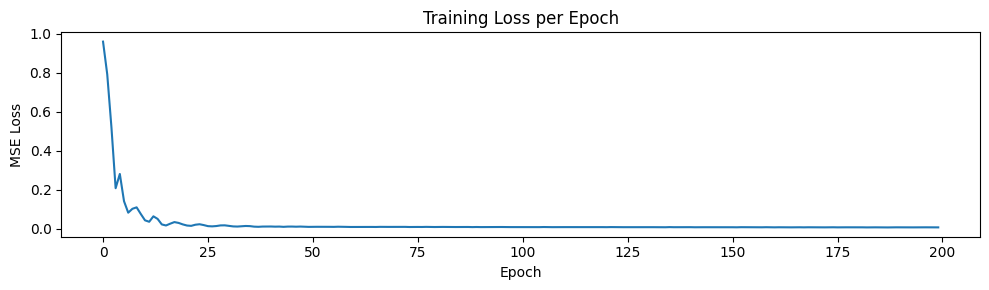

In [24]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(train_losses)
ax.set_title('Training Loss per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
plt.tight_layout()
plt.show()

## Predict & Inverse Transform

Predictions come out in scaled space (mean=0, std=1).
We use `inverse_transform` to convert them back to the original price scale (USD).

In [25]:
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_t).cpu().numpy()  # shape: (samples, 1)

# Inverse transform: back to USD prices
predictions = scaler.inverse_transform(preds_scaled).flatten()
actuals     = test['Close'].values

print(f"Predictions shape: {predictions.shape}")
print(f"Actuals shape:     {actuals.shape}")

Predictions shape: (302,)
Actuals shape:     (302,)


## Metrics

MAE:  6.3399
RMSE: 8.8092
MAPE: 2.5913%


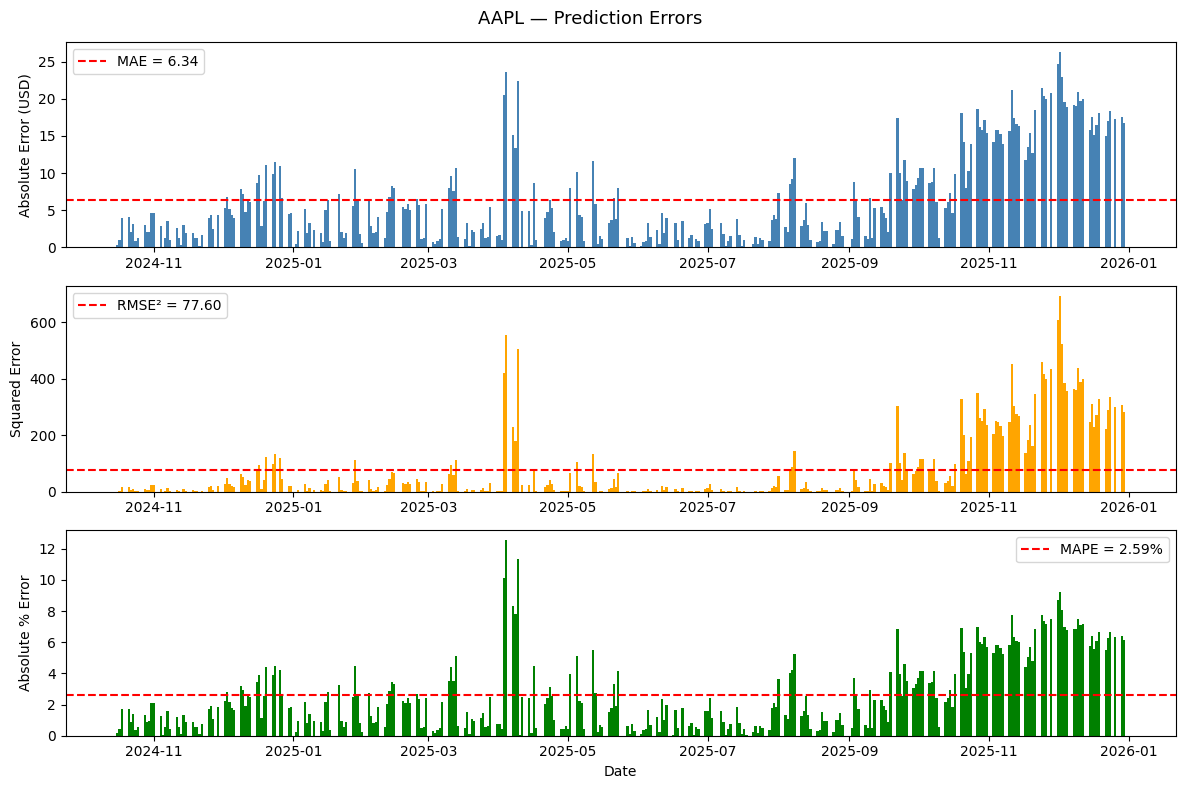

In [26]:
mae  = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

# Daily prediction error (actual - predicted)
errors = actuals - predictions

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle(f'{TICKER} — Prediction Errors', fontsize=13)

# MAE — absolute error per day
axes[0].bar(test.index, np.abs(errors), color='steelblue', width=1)
axes[0].axhline(mae, color='red', linestyle='--', label=f'MAE = {mae:.2f}')
axes[0].set_ylabel('Absolute Error (USD)')
axes[0].legend()

# RMSE — squared error per day (to show which days hurt the most)
axes[1].bar(test.index, errors**2, color='orange', width=1)
axes[1].axhline(rmse**2, color='red', linestyle='--', label=f'RMSE² = {rmse**2:.2f}')
axes[1].set_ylabel('Squared Error')
axes[1].legend()

# MAPE — percentage error per day
pct_errors = np.abs((actuals - predictions) / actuals) * 100
axes[2].bar(test.index, pct_errors, color='green', width=1)
axes[2].axhline(mape, color='red', linestyle='--', label=f'MAPE = {mape:.2f}%')
axes[2].set_ylabel('Absolute % Error')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()

## Plot — Actual vs Predicted

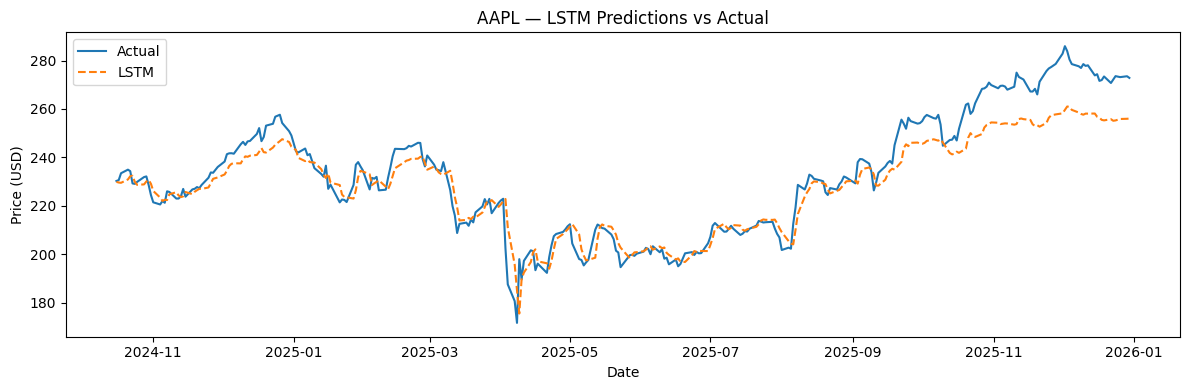

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test.index, actuals,     label='Actual')
ax.plot(test.index, predictions, label='LSTM', linestyle='--')
ax.set_title(f'{TICKER} — LSTM Predictions vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

## Save Results

Save predictions to `data/results/` so the model comparison notebook can load them.


In [28]:
import os
os.makedirs('../data/results', exist_ok=True)

results = pd.DataFrame({
    'Actual':    actuals,
    'Predicted': predictions,
}, index=test.index)

results.to_csv(f'../data/results/lstm_{TICKER}.csv')
print(f"Saved to data/results/lstm_{TICKER}.csv")


Saved to data/results/lstm_AAPL.csv
